# Imports 

In [6]:
import pandas as pd
import numpy as np
import joblib
import sys
import os
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from scipy.stats import t
import copy 
import pprint
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_selection import r_regression
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

In [7]:
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [8]:
from src.functions import Regressor
method=Regressor()

In [9]:
path_to_dev = "../data/assignment1_dev_set.csv"
path_to_val = "../data/assignment1_val_set.csv"

dev_set_df=method.load_data(path_to_dev)
print(dev_set_df)
val_set_df=method.load_data(path_to_val)
print(val_set_df)

Data for development:
     Unnamed: 0   Project ID Experiment type     Sex  Host age    BMI  \
0             0   PRJEB11419    Metagenomics    Male      53.0  19.01   
1             1  PRJNA388263    Metagenomics  Female      21.0  23.50   
2             2  PRJNA388263    Metagenomics    Male      52.0  25.80   
3             3   PRJEB11419    Metagenomics  Female      40.0  23.49   
4             4   PRJEB11419    Metagenomics  Female      30.0  22.60   
..          ...          ...             ...     ...       ...    ...   
484         484  PRJNA397219    Metagenomics    Male      60.0  24.97   
485         485  PRJNA388263    Metagenomics    Male      52.0  25.80   
486         486  PRJNA397219    Metagenomics    Male      78.0  29.53   
487         487   PRJEB11419    Metagenomics    Male      43.0  25.55   
488         488  PRJNA485797    Metagenomics  Female      51.0  22.59   

    Disease MESH ID  Acholeplasma axanthum  Acidaminococcus fermentans  \
0           D006262        

In [10]:
path_to_final_dev = "../data/development_final_data.csv"
path_to_final_val = "../data/evaluation_final_data.csv"

dev_reduced_df=method.preprocess_data(dev_set_df, path_to_final_dev, columns_to_drop=['Unnamed: 0', 'Project ID', 'Experiment type', 'Disease MESH ID'], scale=False)
print(dev_reduced_df)
val_reduced_df=method.preprocess_data(val_set_df, path_to_final_val, columns_to_drop=['Unnamed: 0', 'Project ID', 'Experiment type', 'Disease MESH ID'], scale=False)
print(val_reduced_df)

The preprocessed data was saved to ../data/development_final_data.csv.
     Sex  Host age    BMI  Acholeplasma axanthum  Acidaminococcus fermentans  \
0      1      53.0  19.01               0.000000                    0.000000   
1      0      21.0  23.50               0.001028                    0.000000   
2      1      52.0  25.80               0.001406                    0.000000   
3      0      40.0  23.49               0.000000                    0.008825   
4      0      30.0  22.60               0.002878                    0.037419   
..   ...       ...    ...                    ...                         ...   
484    1      60.0  24.97               0.000000                    0.000000   
485    1      52.0  25.80               0.000000                    0.000000   
486    1      78.0  29.53               0.000000                    0.000000   
487    1      43.0  25.55               0.001556                    0.001556   
488    0      51.0  22.59               0.000000 

## Baseline: No feature selection, no model-tuning

In [11]:
method=Regressor()
X, y = method.separate_features_target(dev_reduced_df, target='BMI', columns_to_remove=['Sex', 'Host age'])
print(X)
print(y)

     Acholeplasma axanthum  Acidaminococcus fermentans  \
0                 0.000000                    0.000000   
1                 0.001028                    0.000000   
2                 0.001406                    0.000000   
3                 0.000000                    0.008825   
4                 0.002878                    0.037419   
..                     ...                         ...   
484               0.000000                    0.000000   
485               0.000000                    0.000000   
486               0.000000                    0.000000   
487               0.001556                    0.001556   
488               0.000000                    0.011382   

     Acidaminococcus intestini  Actinomyces lingnae  Akkermansia muciniphila  \
0                     0.000000             0.000000                 0.017674   
1                     0.000000             0.000000                13.015800   
2                     0.000000             0.001406            

In [12]:
print('Results from baseline untuned models trained on the entire feature set:')
baseline_results=method.train_models(X, y, scale=True)

Results from baseline untuned models trained on the entire feature set:
enet RMSE: 3.8336
svr RMSE: 3.7125
breg RMSE: 3.7868


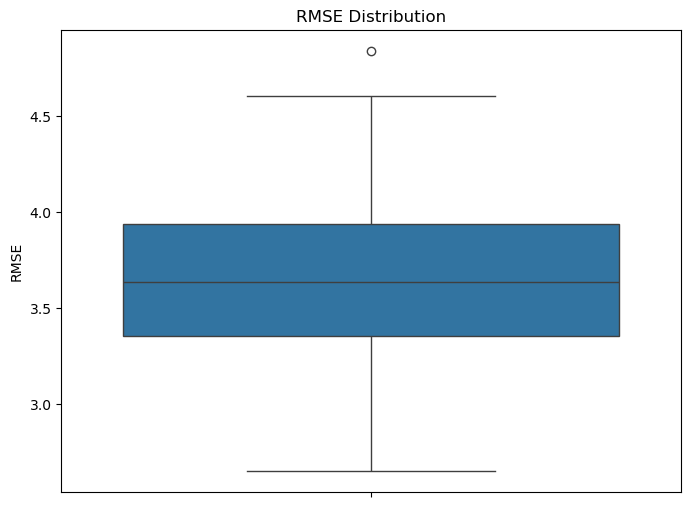

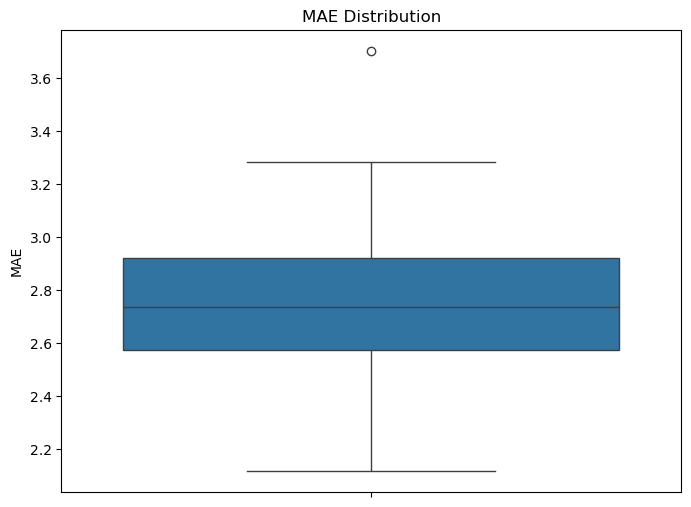

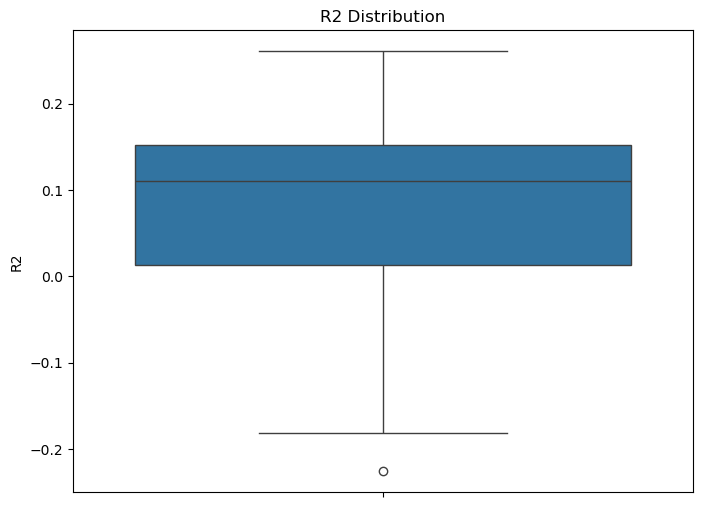

Evaluation Metric results from baseline ElasticNet model:
          mean    median                                     95% CI
rmse  3.690345  3.637328     (3.550264551806514, 3.830425766292701)
mae   2.755646  2.736019   (2.6750591373678643, 2.8362323291107088)
r2    0.075341  0.110062  (0.04494406922190401, 0.1057376011748591)


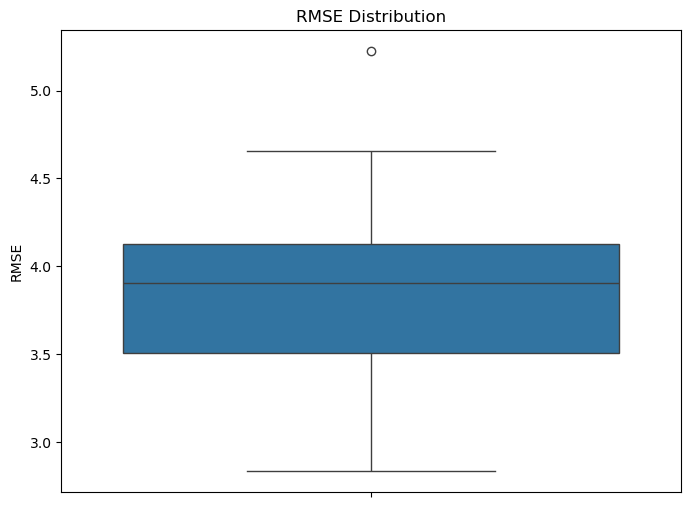

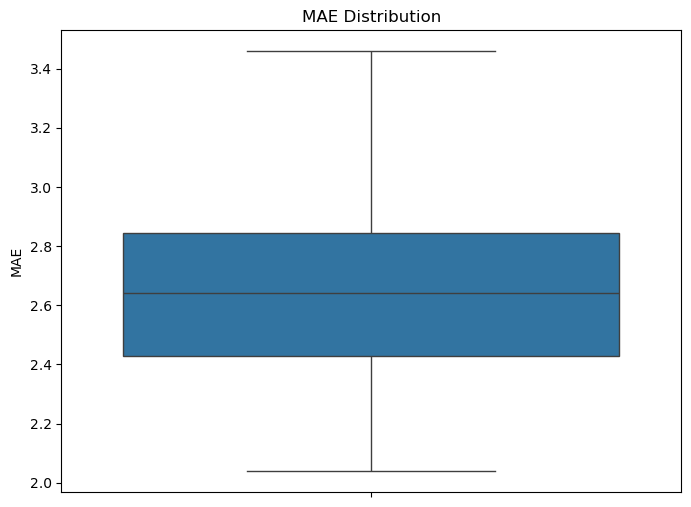

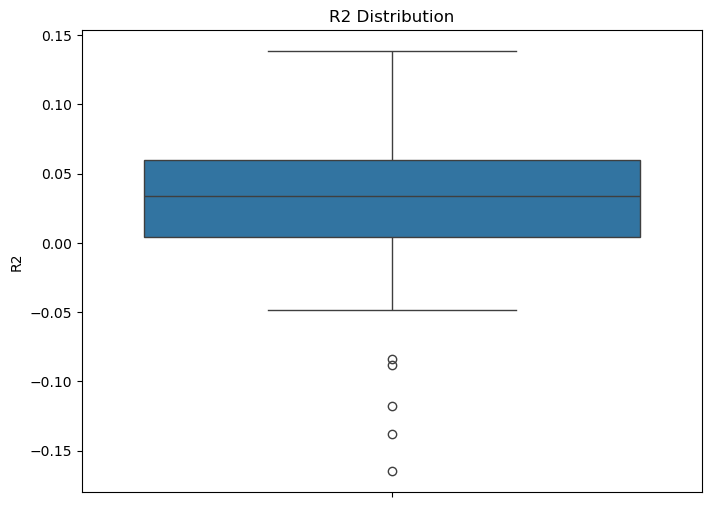

Evaluation Metric results from baseline SVR model:
          mean    median                                       95% CI
rmse  3.828170  3.903573     (3.6857951801781748, 3.9705450035822225)
mae   2.631516  2.641144        (2.546334006791878, 2.71669879703908)
r2    0.024143  0.033835  (0.006373961788338461, 0.04191256324747558)


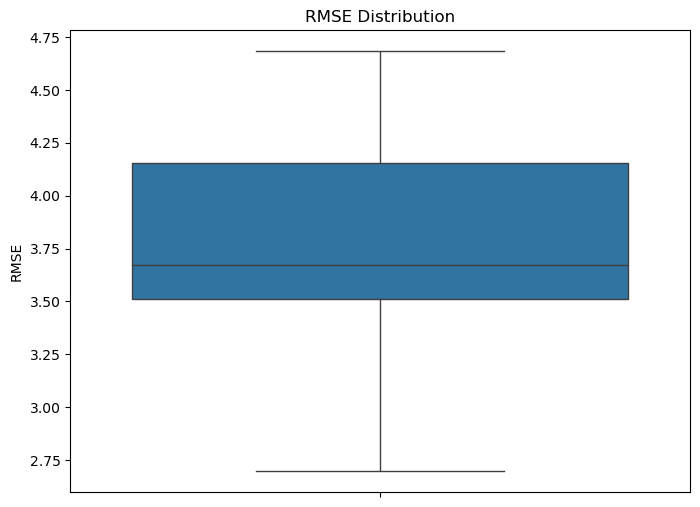

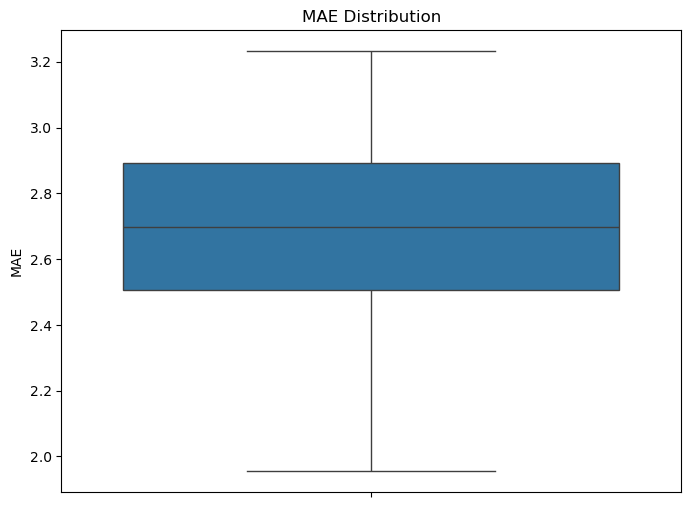

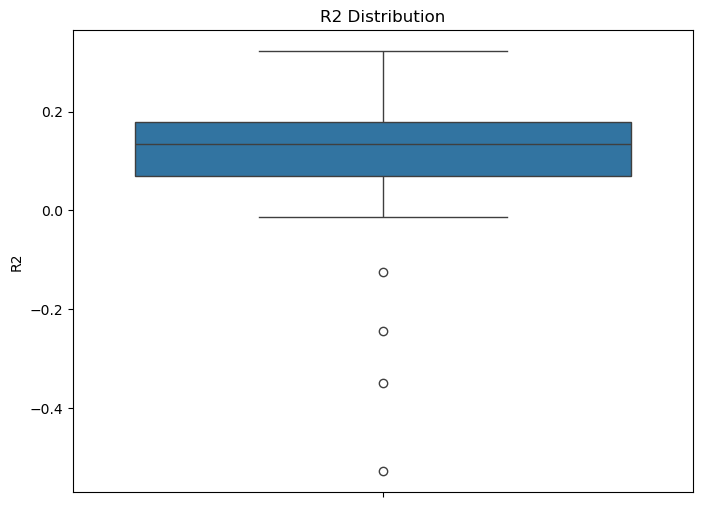

Evaluation Metric results from baseline Bayesianregression model:
          mean    median                                      95% CI
rmse  3.779472  3.672438      (3.645979793987714, 3.912964370877557)
mae   2.676691  2.698360     (2.595987753595892, 2.7573936354524373)
r2    0.101228  0.133671  (0.05796888862575064, 0.14448782770588817)


In [13]:
# Since no feature selection took place for this part of our model analysis, therewas no need for evaluation set alignment to the developmet set
# We have to distinguish the target and the features of the val_reduced_df, since this is the set used for the evaluation part

X, y = method.separate_features_target(val_reduced_df, target='BMI', columns_to_remove=['Sex', 'Host age'])

# model_instance-> ElasticNet with default parameters and no feauture selection
enet_results= method.evaluate_model(ElasticNet(), X, y, runs=50, test_size=0.3, save_path=None)
nofs_nomt_enet_df_summary = pd.DataFrame.from_dict(enet_results, orient='index')
print('Evaluation Metric results from baseline ElasticNet model:')
print(nofs_nomt_enet_df_summary)

# model_instance-> SVR with default parameters and no feauture selection
svr_results= method.evaluate_model(SVR(), X, y, runs=50, test_size=0.3, save_path=None)
nofs_nomt_svr_df_summary = pd.DataFrame.from_dict(svr_results, orient='index')
print('Evaluation Metric results from baseline SVR model:')
print(nofs_nomt_svr_df_summary)

# model_instance-> SVR with default parameters and no feauture selection
breg_results= method.evaluate_model(BayesianRidge(), X, y, runs=50, test_size=0.3, save_path=None)
nofs_nomt_breg_df_summary = pd.DataFrame.from_dict(breg_results, orient='index')
print('Evaluation Metric results from baseline Bayesianregression model:')
print(nofs_nomt_breg_df_summary)


## Feature Selection, No Model-Tuning

In [14]:
X, y = method.separate_features_target(dev_reduced_df, target='BMI', columns_to_remove=['Sex', 'Host age'])
selected_features, correlations=method.select_features(X, y, threshold=0.08)
print(selected_features)

X_selected=X[selected_features]
print(X_selected)

selected_feature_names = X_selected.columns.tolist()
target = 'BMI'
dev_selected_df = dev_reduced_df[selected_feature_names + [target]]
print(dev_selected_df)

The selected features of 134 were: 29
['Alistipes putredinis', 'Anaerotruncus colihominis', 'Bacillus megaterium', 'Bacteroides massiliensis', 'Bifidobacterium saguini', 'Christensenella minuta', 'Clostridium amylolyticum', 'Desulfonispora thiosulfatigenes', 'Desulfovibrio desulfuricans', 'Lachnospiraceae bacterium 7_1_58FAA', 'Oscillibacter valericigenes', 'Papillibacter cinnamivorans', 'Parabacteroides johnsonii', 'Pseudoflavonifractor capillosus', 'Ruminiclostridium thermocellum', 'Ruminococcus albus', 'Ruminococcus champanellensis', 'Ruminococcus flavefaciens', 'Sporobacter termitidis', 'Bacteroides pectinophilus', 'Clostridium asparagiforme', 'Clostridium clariflavum', 'Clostridium colinum', 'Clostridium propionicum', 'Clostridium stercorarium', 'Clostridium symbiosum', 'Eubacterium brachy', 'Eubacterium dolichum', 'Eubacterium sulci']
     Alistipes putredinis  Anaerotruncus colihominis  Bacillus megaterium  \
0                0.005891                   0.000000             0.005

In [15]:
X, y = method.separate_features_target(dev_selected_df, target='BMI', columns_to_remove=None)
print(X)

print('Results from un-tuned model trained on selected features:')
stage_three_results=method.train_models(X, y)


     Alistipes putredinis  Anaerotruncus colihominis  Bacillus megaterium  \
0                0.005891                   0.000000             0.005891   
1                0.403916                   0.107916             0.000000   
2                0.105459                   0.008437             0.000000   
3                0.586834                   0.207377             0.000000   
4                1.004550                   0.126648             0.000000   
..                    ...                        ...                  ...   
484              2.620060                   0.000000             0.000000   
485              0.226497                   0.001180             0.000000   
486              1.722580                   1.618390             0.000000   
487              0.455776                   0.087111             0.000000   
488              1.684590                   1.024420             0.000000   

     Bacteroides massiliensis  Bifidobacterium saguini  \
0                

Evaluation dataset was aligned to development feature set.
     Alistipes putredinis  Anaerotruncus colihominis  Bacillus megaterium  \
0                0.493412                   0.556401             0.000000   
1                0.000000                   0.000000             0.000000   
2                0.714301                   0.048179             0.000000   
3                0.034614                   0.003461             0.006923   
4                0.000000                   0.000000             0.000000   
..                    ...                        ...                  ...   
206              0.383935                   0.186916             0.000000   
207              0.000000                   0.000000             0.000000   
208              0.103121                   0.001452             0.000000   
209              1.314530                   0.292709             0.000000   
210              3.876410                   0.098810             0.003800   

     Bacteroides

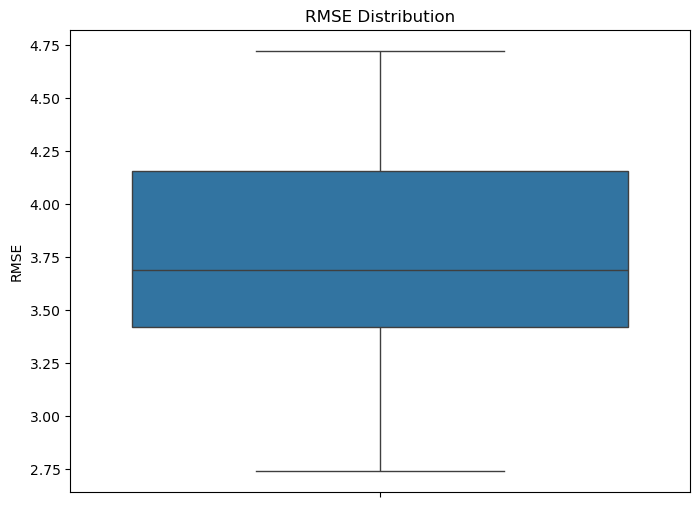

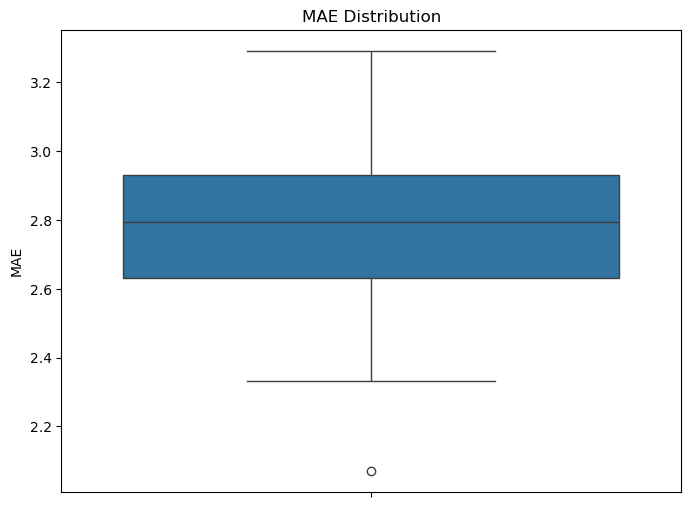

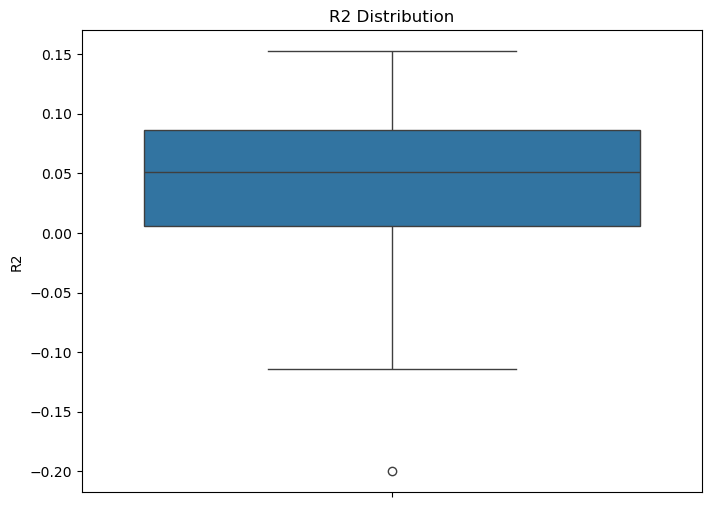

Evaluation Metric results from ElasticNet model with default parameters, trained on selected features:
          mean    median                                      95% CI
rmse  3.761323  3.689815     (3.6218925004196443, 3.900753897394499)
mae   2.796306  2.794239      (2.7203247744553853, 2.87228629998194)
r2    0.040216  0.050746  (0.02049867966474247, 0.05993392980358214)


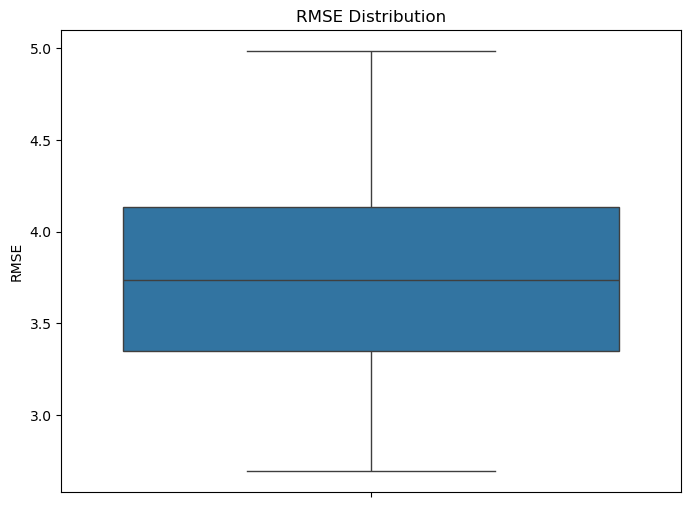

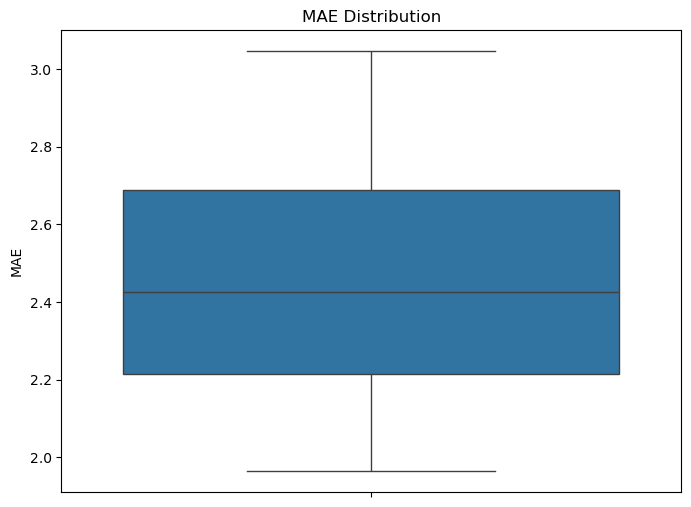

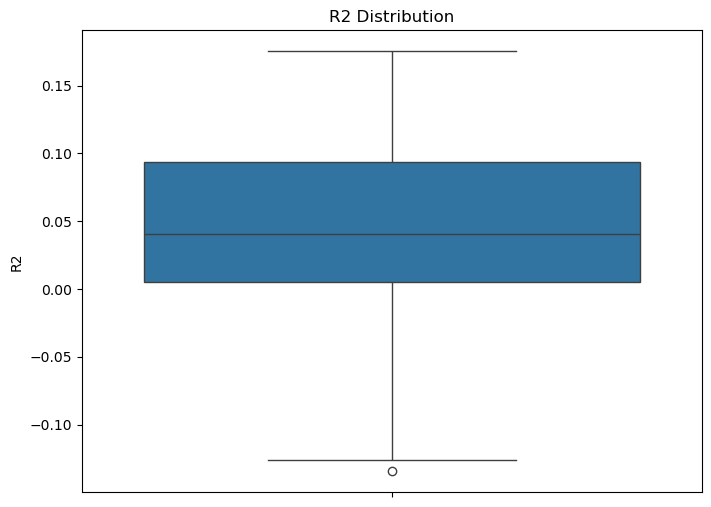

Evaluation Metric results from SVR model with default parameters, trained on selected features:
          mean    median                                       95% CI
rmse  3.760516  3.736986      (3.5983121982452855, 3.922720432803255)
mae   2.449571  2.425675      (2.360731361534375, 2.5384112961377094)
r2    0.045318  0.040885  (0.025506855164583484, 0.06513010239486794)


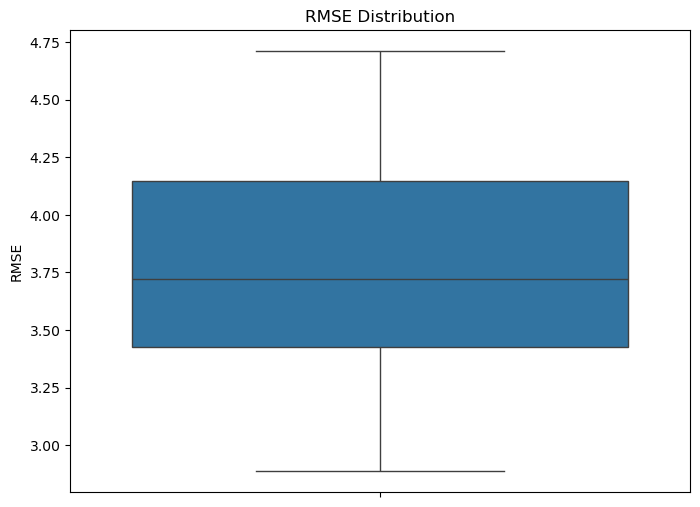

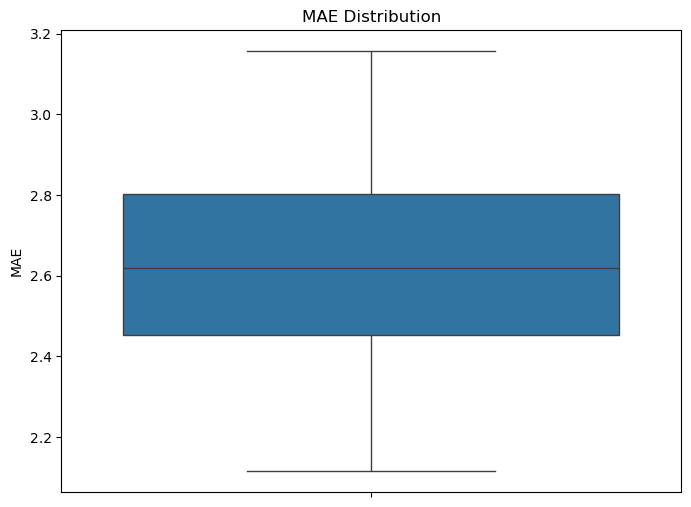

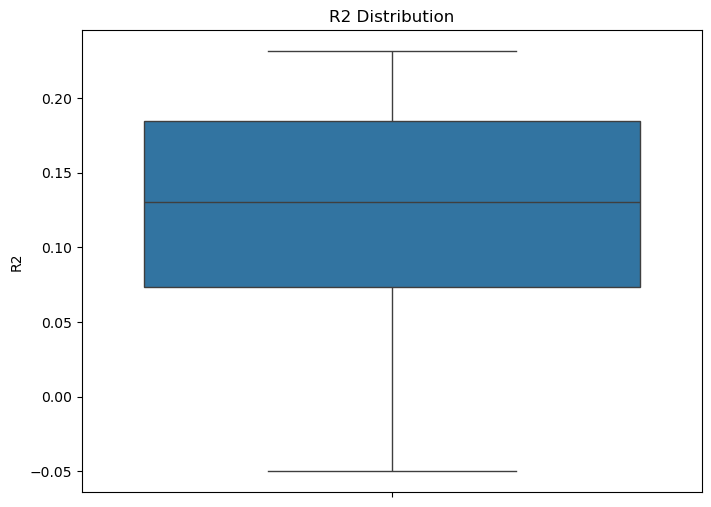

Evaluation Metric results from BayesianRidge model with default parameters, trained on selected features:
          mean    median                                     95% CI
rmse  3.776205  3.721904   (3.6496195495074684, 3.9027895196215754)
mae   2.625457  2.618802   (2.5536357444223063, 2.6972783513399716)
r2    0.126841  0.130497  (0.10702472064640078, 0.1466575387676925)


In [16]:
val_selected_df=method.align_evaluation_set(dev_selected_df, val_reduced_df)

X, y = method.separate_features_target(val_selected_df, target='BMI', columns_to_remove=None)
print(X)

# model_instance-> ElasticNet trained on selected features with default parameters
enet_results= method.evaluate_model(ElasticNet(), X, y, runs=50, test_size=0.3, save_path=None)
nomt_enet_df_summary = pd.DataFrame.from_dict(enet_results, orient='index')
print('Evaluation Metric results from ElasticNet model with default parameters, trained on selected features:')
print(nomt_enet_df_summary)

# model_instance-> SVR trained on selected features with default parameters
svr_results= method.evaluate_model(SVR(), X, y, runs=50, test_size=0.3, save_path=None)
nomt_svr_df_summary = pd.DataFrame.from_dict(svr_results, orient='index')
print('Evaluation Metric results from SVR model with default parameters, trained on selected features:')
print(nomt_svr_df_summary)

# model_instance-> BayesianRidge trained on selected features with default parameters
breg_results= method.evaluate_model(BayesianRidge(), X, y, runs=50, test_size=0.3, save_path=None)
nomt_breg_df_summary = pd.DataFrame.from_dict(breg_results, orient='index')
print('Evaluation Metric results from BayesianRidge model with default parameters, trained on selected features:')
print(nomt_breg_df_summary)


## Model trained on selected features and tuned.

In [17]:
param_grid = {
            'enet': {
                'alpha': [0.01, 0.1, 1.0],
                'l1_ratio': [0.2, 0.5, 0.8]
            },
            'svr': {
                'C': [0.1, 1, 10],
                'epsilon': [0.01, 0.1],
                'kernel': ['rbf', 'linear']
            },
            'breg': {
                'alpha_1': [1e-6, 1e-5],
                'lambda_1': [1e-6, 1e-5]
            }
        }

model_combinations=method.generate_param_combintions(param_grid)
model_combo_df_summary = pd.DataFrame.from_dict(model_combinations, orient='index')
print(model_combo_df_summary)

                                                0   \
enet              {'alpha': 0.01, 'l1_ratio': 0.2}   
svr   {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}   
breg         {'alpha_1': 1e-06, 'lambda_1': 1e-06}   

                                                   1   \
enet                 {'alpha': 0.01, 'l1_ratio': 0.5}   
svr   {'C': 0.1, 'epsilon': 0.01, 'kernel': 'linear'}   
breg            {'alpha_1': 1e-06, 'lambda_1': 1e-05}   

                                               2   \
enet             {'alpha': 0.01, 'l1_ratio': 0.8}   
svr   {'C': 0.1, 'epsilon': 0.1, 'kernel': 'rbf'}   
breg        {'alpha_1': 1e-05, 'lambda_1': 1e-06}   

                                                  3   \
enet                 {'alpha': 0.1, 'l1_ratio': 0.2}   
svr   {'C': 0.1, 'epsilon': 0.1, 'kernel': 'linear'}   
breg           {'alpha_1': 1e-05, 'lambda_1': 1e-05}   

                                              4   \
enet             {'alpha': 0.1, 'l1_ratio': 0.5}   
svr   {'C': 

In [18]:
X, y = method.separate_features_target(dev_selected_df, target='BMI', columns_to_remove=None)
print(X) #make sure that X:489x29

best_results=method.model_tuning(param_grid, X, y, cv=5)
print(best_results['enet'])
print(best_results['svr'])
print(best_results['breg'])

     Alistipes putredinis  Anaerotruncus colihominis  Bacillus megaterium  \
0                0.005891                   0.000000             0.005891   
1                0.403916                   0.107916             0.000000   
2                0.105459                   0.008437             0.000000   
3                0.586834                   0.207377             0.000000   
4                1.004550                   0.126648             0.000000   
..                    ...                        ...                  ...   
484              2.620060                   0.000000             0.000000   
485              0.226497                   0.001180             0.000000   
486              1.722580                   1.618390             0.000000   
487              0.455776                   0.087111             0.000000   
488              1.684590                   1.024420             0.000000   

     Bacteroides massiliensis  Bifidobacterium saguini  \
0                

In [19]:
enet_rmse=method.train_tuned_model(ElasticNet(l1_ratio=0.2), X, y, scale=True)
svr_rmse=method.train_tuned_model(SVR(C=1, epsilon=0.01, kernel='linear'), X, y, scale=True)
breg_rmse=method.train_tuned_model(BayesianRidge(lambda_1=1e-05), X, y, scale=True)

Model: ElasticNet RMSE: 3.7768
Model: SVR RMSE: 3.7758
Model: BayesianRidge RMSE: 3.8863


Evaluation dataset was aligned to development feature set.
     Alistipes putredinis  Anaerotruncus colihominis  Bacillus megaterium  \
0                0.493412                   0.556401             0.000000   
1                0.000000                   0.000000             0.000000   
2                0.714301                   0.048179             0.000000   
3                0.034614                   0.003461             0.006923   
4                0.000000                   0.000000             0.000000   
..                    ...                        ...                  ...   
206              0.383935                   0.186916             0.000000   
207              0.000000                   0.000000             0.000000   
208              0.103121                   0.001452             0.000000   
209              1.314530                   0.292709             0.000000   
210              3.876410                   0.098810             0.003800   

     Bacteroides

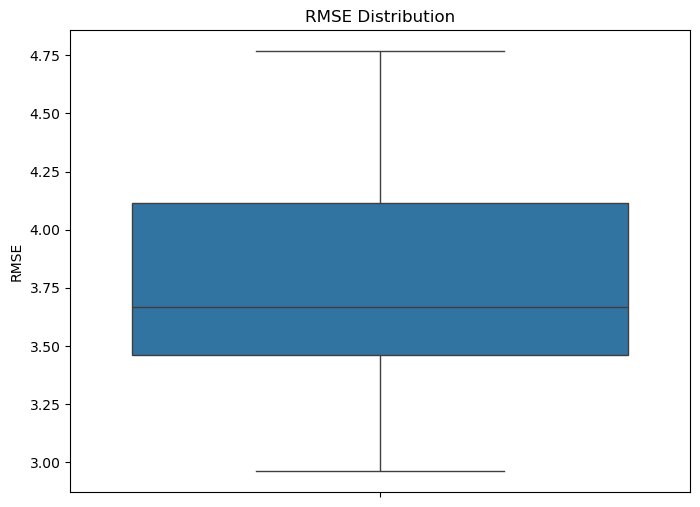

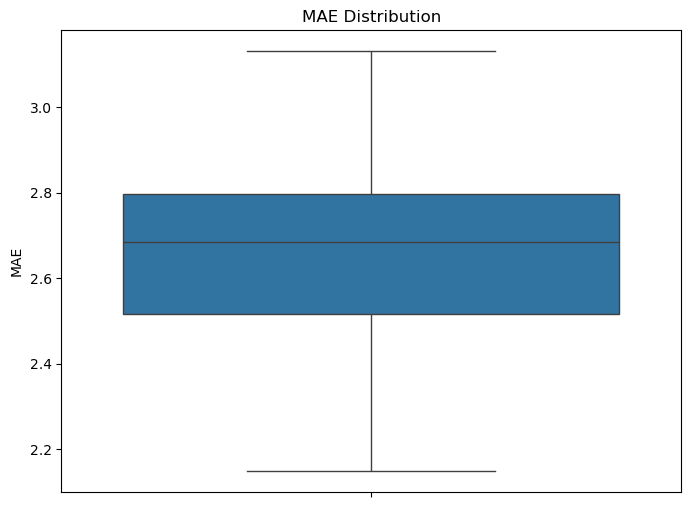

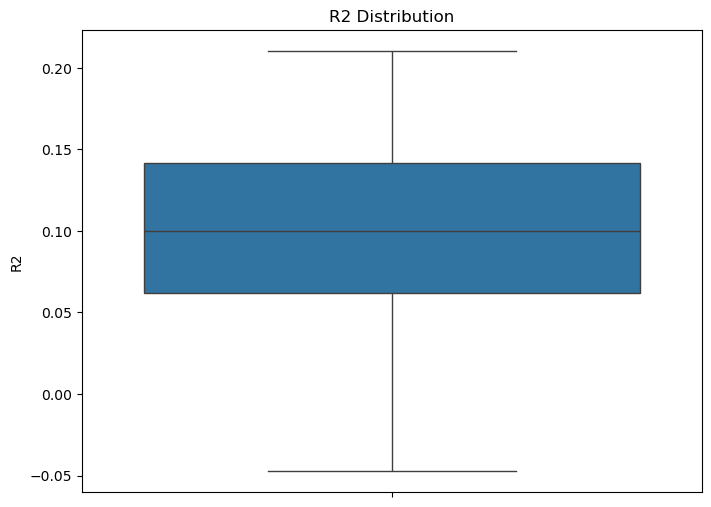

Evaluation Metric results from tuned ElasticNet model trained on selected features:
          mean    median                                      95% CI
rmse  3.743531  3.666941    (3.6195324998006533, 3.8675294216231033)
mae   2.655873  2.683760     (2.5936240862220856, 2.718121775913862)
r2    0.099203  0.100016  (0.08143700823163687, 0.11696804453650682)
Best model (lowest RMSE: 2.7708) saved to ../final_models/final_svr.pkl


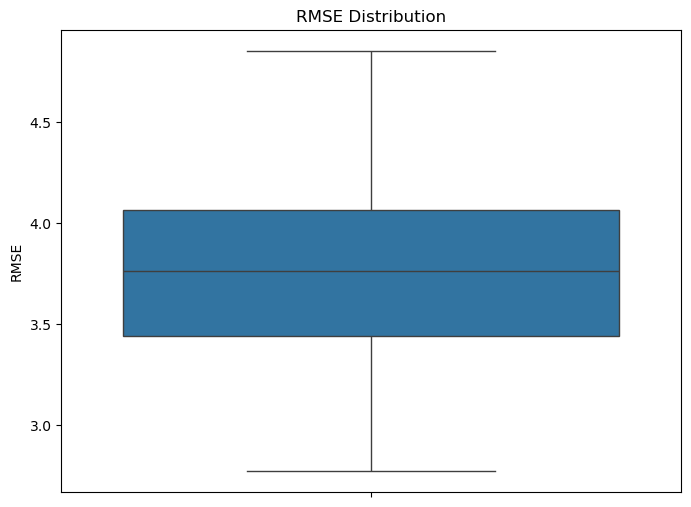

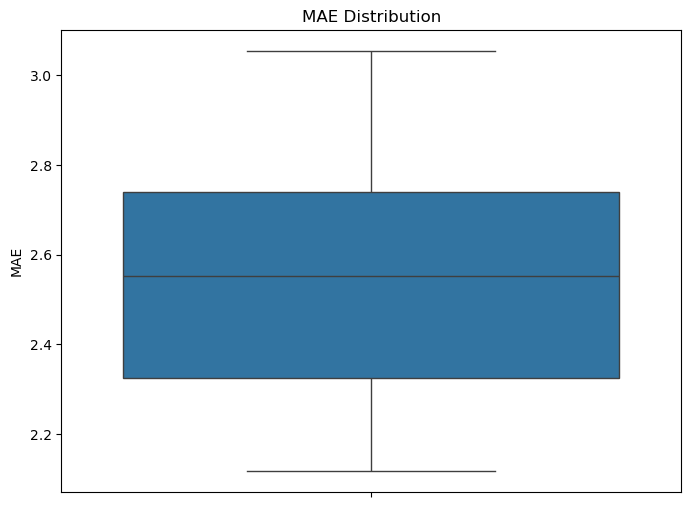

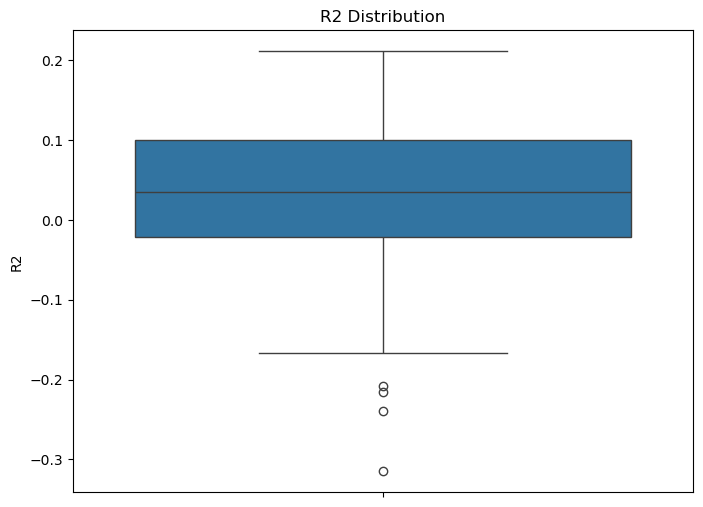

Evaluation Metric results from tuned SVR model trained on selected features:
          mean    median                                        95% CI
rmse  3.734629  3.763780        (3.608017360733778, 3.861241267293045)
mae   2.542057  2.552637       (2.470606643353207, 2.6135071517095345)
r2    0.023687  0.035202  (-0.009633551637064253, 0.05700693540922347)
Best model (lowest RMSE: 2.8884) saved to ../final_models/final_breg.pkl


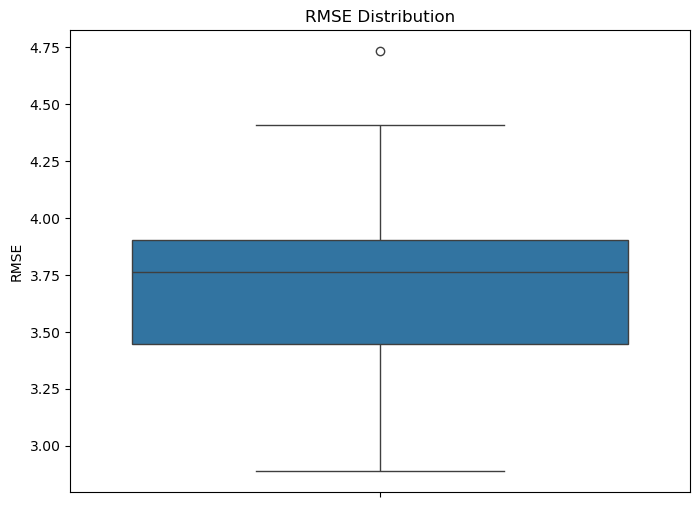

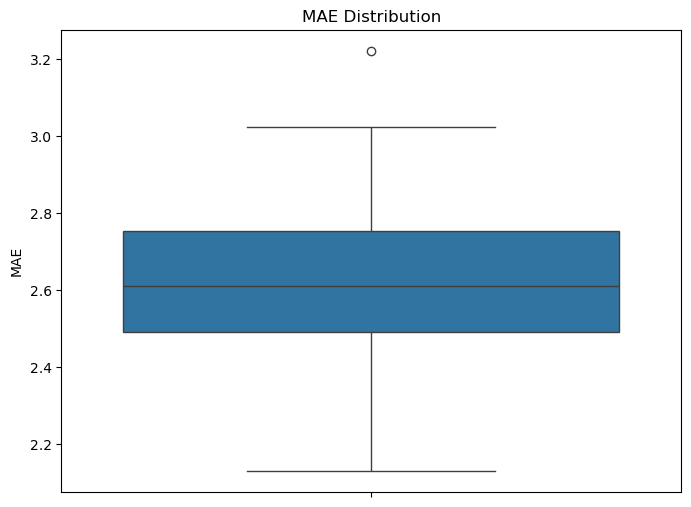

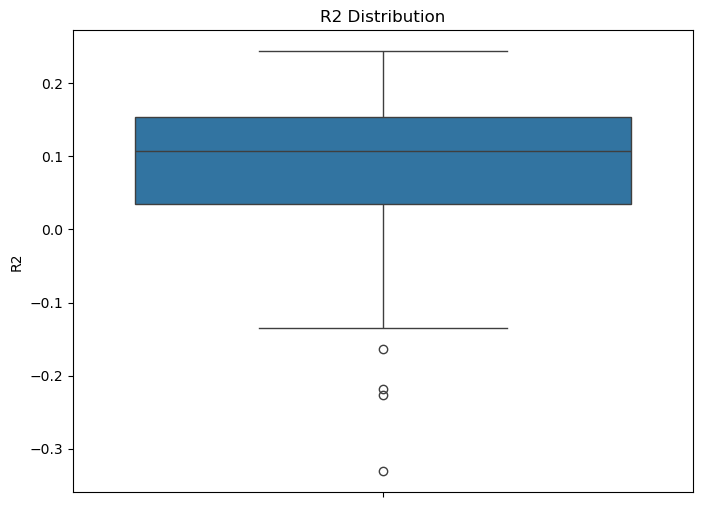

Evaluation Metric results from tuned BayesianRidge model trained on selected features:
          mean    median                                      95% CI
rmse  3.727500  3.764190    (3.6256219555700886, 3.8293780678875375)
mae   2.624936  2.610040      (2.56266460868382, 2.6872067762508682)
r2    0.074894  0.107086  (0.03974905974959341, 0.11003979079983392)


In [20]:
val_selected_df=method.align_evaluation_set(dev_selected_df, val_reduced_df)

X, y = method.separate_features_target(val_selected_df, target='BMI', columns_to_remove=None)
print(X)

# model_instance-> ElasticNet tuned and trained on selected features
enet_results= method.evaluate_model(ElasticNet(l1_ratio=0.2), X, y, runs=50, test_size=0.3, save_path="../final_models/final_enet.pkl")
fs_and_t_enet_df_summary = pd.DataFrame.from_dict(enet_results, orient='index')
print('Evaluation Metric results from tuned ElasticNet model trained on selected features:')
print(fs_and_t_enet_df_summary)

# model_instance-> SVR tuned and trained on selected features
svr_results= method.evaluate_model(SVR(C=10, epsilon=0.01), X, y, runs=50, test_size=0.3, save_path="../final_models/final_svr.pkl")
fs_and_t_svr_df_summary = pd.DataFrame.from_dict(svr_results, orient='index')
print('Evaluation Metric results from tuned SVR model trained on selected features:')
print(fs_and_t_svr_df_summary)

# model_instance-> BayesianRidge tuned and trained on selected features 
breg_results= method.evaluate_model(BayesianRidge(lambda_1=1e-05), X, y, runs=50, test_size=0.3, save_path="../final_models/final_breg.pkl")
fs_and_t_breg_df_summary = pd.DataFrame.from_dict(breg_results, orient='index')
print('Evaluation Metric results from tuned BayesianRidge model trained on selected features:')
print(fs_and_t_breg_df_summary)
